## Import Libraries

In [90]:
# for data handling and manuplation
import pandas as pd
import numpy as np

# for data visulization
import matplotlib.pyplot as plt
import seaborn as sns

# show all columns
pd.set_option('display.max_columns', None)

## Load datasets

In [91]:
train_df = pd.read_csv(r'./data/train.csv', low_memory=False)
test_df = pd.read_csv(r'./data/test.csv', low_memory=False)
store_df = pd.read_csv(r'./data/store.csv', low_memory=False)

## Cleaning and EDA

Let's take a look at all the DataFrames:

In [92]:
train_df

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1
...,...,...,...,...,...,...,...,...,...
1017204,1111,2,2013-01-01,0,0,0,0,a,1
1017205,1112,2,2013-01-01,0,0,0,0,a,1
1017206,1113,2,2013-01-01,0,0,0,0,a,1
1017207,1114,2,2013-01-01,0,0,0,0,a,1


In [93]:
store_df

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
1110,1111,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
1111,1112,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
1112,1113,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
1113,1114,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN


**NOTES:**
- `Promo2` is store-level flag for a continuing, recurring promotion that some stores take part in, It describes the store, not the day.
- `Promo2Since[Year/Week]` describes the year and calendar week when the store started participating in Promo2
- `PromoInterval`: the months in which Promo2 starts a new round. For example, "Feb,May,Aug,Nov" means a new round begins in those months every year.

In [94]:
test_df

,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday
0,1,1,4,2015-09-17,1.0,1,0,0
1,2,3,4,2015-09-17,1.0,1,0,0
2,3,7,4,2015-09-17,1.0,1,0,0
3,4,8,4,2015-09-17,1.0,1,0,0
4,5,9,4,2015-09-17,1.0,1,0,0
...,...,...,...,...,...,...,...,...
41083,41084,1111,6,2015-08-01,1.0,0,0,0
41084,41085,1112,6,2015-08-01,1.0,0,0,0
41085,41086,1113,6,2015-08-01,1.0,0,0,0
41086,41087,1114,6,2015-08-01,1.0,0,0,0


Let's investigate the NULLs values:

In [95]:
train_df.isnull().sum()

Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64

No Null values in `train_df`.

What about `store_df`?

In [96]:
store_df.isnull().sum()

Store                          0
StoreType                      0
Assortment                     0
CompetitionDistance            3
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
Promo2                         0
Promo2SinceWeek              544
Promo2SinceYear              544
PromoInterval                544
dtype: int64

Let's handle these one-by-none:

In [97]:
# CompetitionDistance missing values
store_df[pd.isnull(store_df['CompetitionDistance'])]

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
290,291,d,a,NaN,NaN,NaN,0,NaN,NaN,NaN
621,622,a,c,NaN,NaN,NaN,0,NaN,NaN,NaN
878,879,d,a,NaN,NaN,NaN,1,5.0,2013.0,"Feb,May,Aug,Nov"


Apparently this information is simply missing from the data. No particular pattern observed. In this case, Let's replace NaN with the max value\
(to indicate that competition is very far way):

In [98]:
# replace missing CompetitionDistance
store_df['CompetitionDistance'] = store_df['CompetitionDistance'].fillna(store_df['CompetitionDistance'].max())

Since, `Promo2SinceWeek` = `NULL` means that store never participated in Promos and same goes for `Promo2SinceYear`, `PromoInterval`;\
Let's replace these NULL values with 0s:

In [99]:
# replace missing Promo2SinceWeek, Promo2SinceYear, PromoInterval
store_df = store_df.fillna({'Promo2SinceWeek': 0, 'Promo2SinceYear': 0, 'PromoInterval':0}, inplace=True)

Let's investigate missing `CompetitionOpenSinceMonth` and `CompetitionOpenSinceYear` values:

In [100]:
store_df[pd.isnull(store_df['CompetitionOpenSinceMonth'])]

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
11,12,a,c,1070.0,NaN,NaN,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
12,13,d,a,310.0,NaN,NaN,1,45.0,2009.0,"Feb,May,Aug,Nov"
15,16,a,c,3270.0,NaN,NaN,0,0.0,0.0,0
18,19,a,c,3240.0,NaN,NaN,1,22.0,2011.0,"Mar,Jun,Sept,Dec"
21,22,a,a,1040.0,NaN,NaN,1,22.0,2012.0,"Jan,Apr,Jul,Oct"
...,...,...,...,...,...,...,...,...,...,...
1095,1096,a,c,1130.0,NaN,NaN,1,10.0,2014.0,"Mar,Jun,Sept,Dec"
1099,1100,a,a,540.0,NaN,NaN,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
1112,1113,a,c,9260.0,NaN,NaN,0,0.0,0.0,0
1113,1114,a,c,870.0,NaN,NaN,0,0.0,0.0,0


We'll deal with this during **Feature Engineering**

Let's merge `train_df` and `store_df`(additional information about the stores) for further operations:

In [101]:
merged_df = pd.merge(train_df, store_df, how='left', on='Store')

Let's check the `Dtype` and `Non-Null Count` of `merged_df`:

In [102]:
merged_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   Store                      1017209 non-null  int64  
 1   DayOfWeek                  1017209 non-null  int64  
 2   Date                       1017209 non-null  str    
 3   Sales                      1017209 non-null  int64  
 4   Customers                  1017209 non-null  int64  
 5   Open                       1017209 non-null  int64  
 6   Promo                      1017209 non-null  int64  
 7   StateHoliday               1017209 non-null  str    
 8   SchoolHoliday              1017209 non-null  int64  
 9   StoreType                  1017209 non-null  str    
 10  Assortment                 1017209 non-null  str    
 11  CompetitionDistance        1017209 non-null  float64
 12  CompetitionOpenSinceMonth  693861 non-null   float64
 13  CompetitionOpenSinceYea

Let's convert `Date` to its correct Dtype, we need it for `feature engineering`:

In [103]:
merged_df['Date'] = pd.to_datetime(merged_df['Date'])

---

### Feature Engineering

Let's extract `Year`, `Month`, `Day` from `Date` column:

In [104]:
merged_df['Year'] = merged_df['Date'].dt.year
merged_df['Month'] = merged_df['Date'].dt.month
merged_df['Day'] = merged_df['Date'].dt.day

Next, Let's use the columns `CompetitionOpenSince[Month/Year]` to compute the number of months\
for which a competitior has been open near the store:

In [105]:
merged_df['CompetitionOpen'] = 12 * (merged_df['Year'] - merged_df['CompetitionOpenSinceYear']) + (merged_df['Month'] - merged_df['CompetitionOpenSinceMonth'])

# replace negative and NaN values with 0s
merged_df['CompetitionOpen'] = merged_df['CompetitionOpen'].map(lambda x: 0 if x < 0 else x).fillna(0)

Let's check opened stores with zero sales stores:

In [106]:
open_zero_sales = merged_df[(merged_df['Open'] == 1) & (merged_df['Sales'] == 0)]

In [107]:
open_zero_sales.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Year,Month,Day,CompetitionOpen
86825,971,5,2015-05-15,0,0,1,0,0,1,c,a,1140.0,5.0,2011.0,1,14.0,2012.0,"Mar,Jun,Sept,Dec",2015,5,15,48.0
142278,674,4,2015-03-26,0,0,1,0,0,0,a,a,2640.0,12.0,2005.0,1,31.0,2013.0,"Feb,May,Aug,Nov",2015,3,26,111.0
196938,699,4,2015-02-05,0,0,1,1,0,0,a,a,180.0,NaN,NaN,1,5.0,2013.0,"Jan,Apr,Jul,Oct",2015,2,5,0.0
322053,708,3,2014-10-01,0,0,1,1,0,0,c,c,11470.0,10.0,2009.0,1,18.0,2014.0,"Jan,Apr,Jul,Oct",2014,10,1,60.0
330176,357,1,2014-09-22,0,0,1,0,0,0,a,a,2060.0,10.0,2008.0,0,0.0,0.0,0,2014,9,22,71.0


In [108]:
open_zero_sales.shape

(54, 22)

There're only 54 days in the data where there are opened store with no sales on working days, so we can assume that there were\
external factors involved like public protests, strikes, or demonstrations.

Let's check closed stores with zero sales stores as well:

In [109]:
merged_df[(merged_df['Open'] == 0) & (merged_df['Sales'] == 0)]

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Year,Month,Day,CompetitionOpen
291,292,5,2015-07-31,0,0,0,1,0,1,a,a,1100.0,6.0,2009.0,0,0.0,0.0,0,2015,7,31,73.0
875,876,5,2015-07-31,0,0,0,1,0,1,a,a,21790.0,4.0,2005.0,1,18.0,2015.0,"Feb,May,Aug,Nov",2015,7,31,123.0
1406,292,4,2015-07-30,0,0,0,1,0,1,a,a,1100.0,6.0,2009.0,0,0.0,0.0,0,2015,7,30,73.0
1990,876,4,2015-07-30,0,0,0,1,0,1,a,a,21790.0,4.0,2005.0,1,18.0,2015.0,"Feb,May,Aug,Nov",2015,7,30,123.0
2521,292,3,2015-07-29,0,0,0,1,0,1,a,a,1100.0,6.0,2009.0,0,0.0,0.0,0,2015,7,29,73.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1017204,1111,2,2013-01-01,0,0,0,0,a,1,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct",2013,1,1,0.0
1017205,1112,2,2013-01-01,0,0,0,0,a,1,c,c,1880.0,4.0,2006.0,0,0.0,0.0,0,2013,1,1,81.0
1017206,1113,2,2013-01-01,0,0,0,0,a,1,a,c,9260.0,NaN,NaN,0,0.0,0.0,0,2013,1,1,0.0
1017207,1114,2,2013-01-01,0,0,0,0,a,1,a,c,870.0,NaN,NaN,0,0.0,0.0,0,2013,1,1,0.0


There're 172817 closed stores in the data. It is about 10% of the total amount of observations. To avoid any biased forecasts, Let's drop these values:

In [110]:
merged_df = merged_df[(merged_df['Open'] != 0) & (merged_df['Sales'] != 0)]

---

Let's check the stats of the data:

In [111]:
merged_df.describe()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,SchoolHoliday,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,Year,Month,Day,CompetitionOpen
count,844338.000000,844338.000000,844338,844338.000000,844338.000000,844338.0,844338.000000,844338.000000,844338.000000,575738.000000,575738.000000,844338.000000,844338.000000,844338.000000,844338.000000,844338.000000,844338.000000,844338.000000
mean,558.421374,3.520350,2014-04-11 01:08:38.729703,6955.959134,762.777166,1.0,0.446356,0.193578,5640.427743,7.224842,2008.697753,0.498670,11.596159,1003.201259,2013.831945,5.845774,15.835706,41.953669
min,1.000000,1.000000,2013-01-01 00:00:00,46.000000,8.000000,1.0,0.000000,0.000000,20.000000,1.000000,1900.000000,0.000000,0.000000,0.000000,2013.000000,1.000000,1.000000,0.000000
25%,280.000000,2.000000,2013-08-16 00:00:00,4859.000000,519.000000,1.0,0.000000,0.000000,710.000000,4.000000,2006.000000,0.000000,0.000000,0.000000,2013.000000,3.000000,8.000000,0.000000
50%,558.000000,3.000000,2014-03-31 00:00:00,6369.000000,676.000000,1.0,0.000000,0.000000,2330.000000,8.000000,2010.000000,0.000000,0.000000,0.000000,2014.000000,6.000000,16.000000,16.000000
75%,837.000000,5.000000,2014-12-11 00:00:00,8360.000000,893.000000,1.0,1.000000,0.000000,6910.000000,10.000000,2013.000000,1.000000,22.000000,2012.000000,2014.000000,8.000000,23.000000,73.000000
max,1115.000000,7.000000,2015-07-31 00:00:00,41551.000000,7388.000000,1.0,1.000000,1.000000,75860.000000,12.000000,2015.000000,1.000000,50.000000,2015.000000,2015.000000,12.000000,31.000000,1386.000000
std,321.730861,1.723712,NaN,3103.815515,401.194153,0.0,0.497114,0.395102,8580.824305,3.210118,5.978064,0.499999,15.308101,1005.874685,0.777271,3.323959,8.683392,65.189972


we'll go through each column one-by-one; we'll investigate if necessary:


`Store` is an identifier, not a quantity, so its mean (558.42) and median (558) carry no meaning. The max of 1115 only shows that the largest ID is 1115. It doesn't confirm that all 1,115 stores are present, so I'll verify with `nunique()`.

In [112]:
merged_df['Store'].nunique()

1115

`DayOfWeek` is categorical (1 = Monday ... 7 = Sunday), so the mean (3.52) isn't interpretable either. The useful finding is that the max is 7 even though `Open` is 1 on every row (std = 0), so closed days are already filtered out. That means some stores traded on Sundays, which is unusual. I'll check how many rows that is.

In [113]:
# Check what stores were open even on Sunday
merged_df[(merged_df['DayOfWeek'] == 7) & (merged_df['Open'] == 1)]

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Year,Month,Day,CompetitionOpen
5659,85,7,2015-07-26,11421,1606,1,0,0,0,b,a,1870.0,10.0,2011.0,0,0.0,0.0,0,2015,7,26,45.0
5696,122,7,2015-07-26,5773,707,1,0,0,0,a,c,58260.0,4.0,2013.0,0,0.0,0.0,0,2015,7,26,27.0
5783,209,7,2015-07-26,3742,354,1,0,0,0,a,c,11680.0,9.0,2011.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct",2015,7,26,46.0
5833,259,7,2015-07-26,15998,2857,1,0,0,0,b,b,210.0,NaN,NaN,0,0.0,0.0,0,2015,7,26,0.0
5836,262,7,2015-07-26,32547,4783,1,0,0,0,b,a,1180.0,5.0,2013.0,0,0.0,0.0,0,2015,7,26,26.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1011252,733,7,2013-01-06,11226,2584,1,0,0,0,b,b,860.0,10.0,1999.0,0,0.0,0.0,0,2013,1,6,159.0
1011288,769,7,2013-01-06,6995,1764,1,0,0,0,b,b,840.0,NaN,NaN,1,48.0,2012.0,"Jan,Apr,Jul,Oct",2013,1,6,0.0
1011382,863,7,2013-01-06,2067,255,1,0,0,0,a,c,21370.0,11.0,2010.0,0,0.0,0.0,0,2013,1,6,26.0
1011467,948,7,2013-01-06,6024,1402,1,0,a,0,b,b,1430.0,NaN,NaN,0,0.0,0.0,0,2013,1,6,0.0


Let's look closely at different levels of `StoreType` and how the main metric Sales is distributed among them:

In [114]:
merged_df.groupby('StoreType')['Sales'].describe()

,count,mean,std,min,25%,50%,75%,max
StoreType,,,,,,,,
a,457042.0,6925.697986,3277.351589,46.0,4695.25,6285.0,8406.00,41551.0
b,15560.0,10233.380141,5155.729868,1252.0,6345.75,9130.0,13184.25,38722.0
c,112968.0,6933.126425,2896.958579,133.0,4916.00,6408.0,8349.25,31448.0
d,258768.0,6822.300064,2556.401455,538.0,5050.00,6395.0,8123.25,38037.0


`StoreType b` has the highest average (and median) of `Sales` among all others, however we have much less data for it. So, let's print an overall sum and median of
`Sales` and `Customers` to see which `StoreType` is the most selling and crowded one:

In [115]:
merged_df.groupby('StoreType')[['Customers', 'Sales']].agg(['sum', 'median'])

Customers               Sales        
                 sum  median         sum  median
StoreType                                       
a          363541431   720.0  3165334859  6285.0
b           31465616  1839.5   159231395  9130.0
c           92129705   756.0   783221426  6408.0
d          156904995   577.0  1765392943  6395.0

In lifetime (2 years), `StoreType a` has the most Customers and most Sales; however, On daily basis `StoreType b` is the most Crowded with most Sales.

**Next:** Let's visualize median monthly `Sales` for each `StoreType` (a, b, c, d), with and without a promotion, using `sns.catplot`:

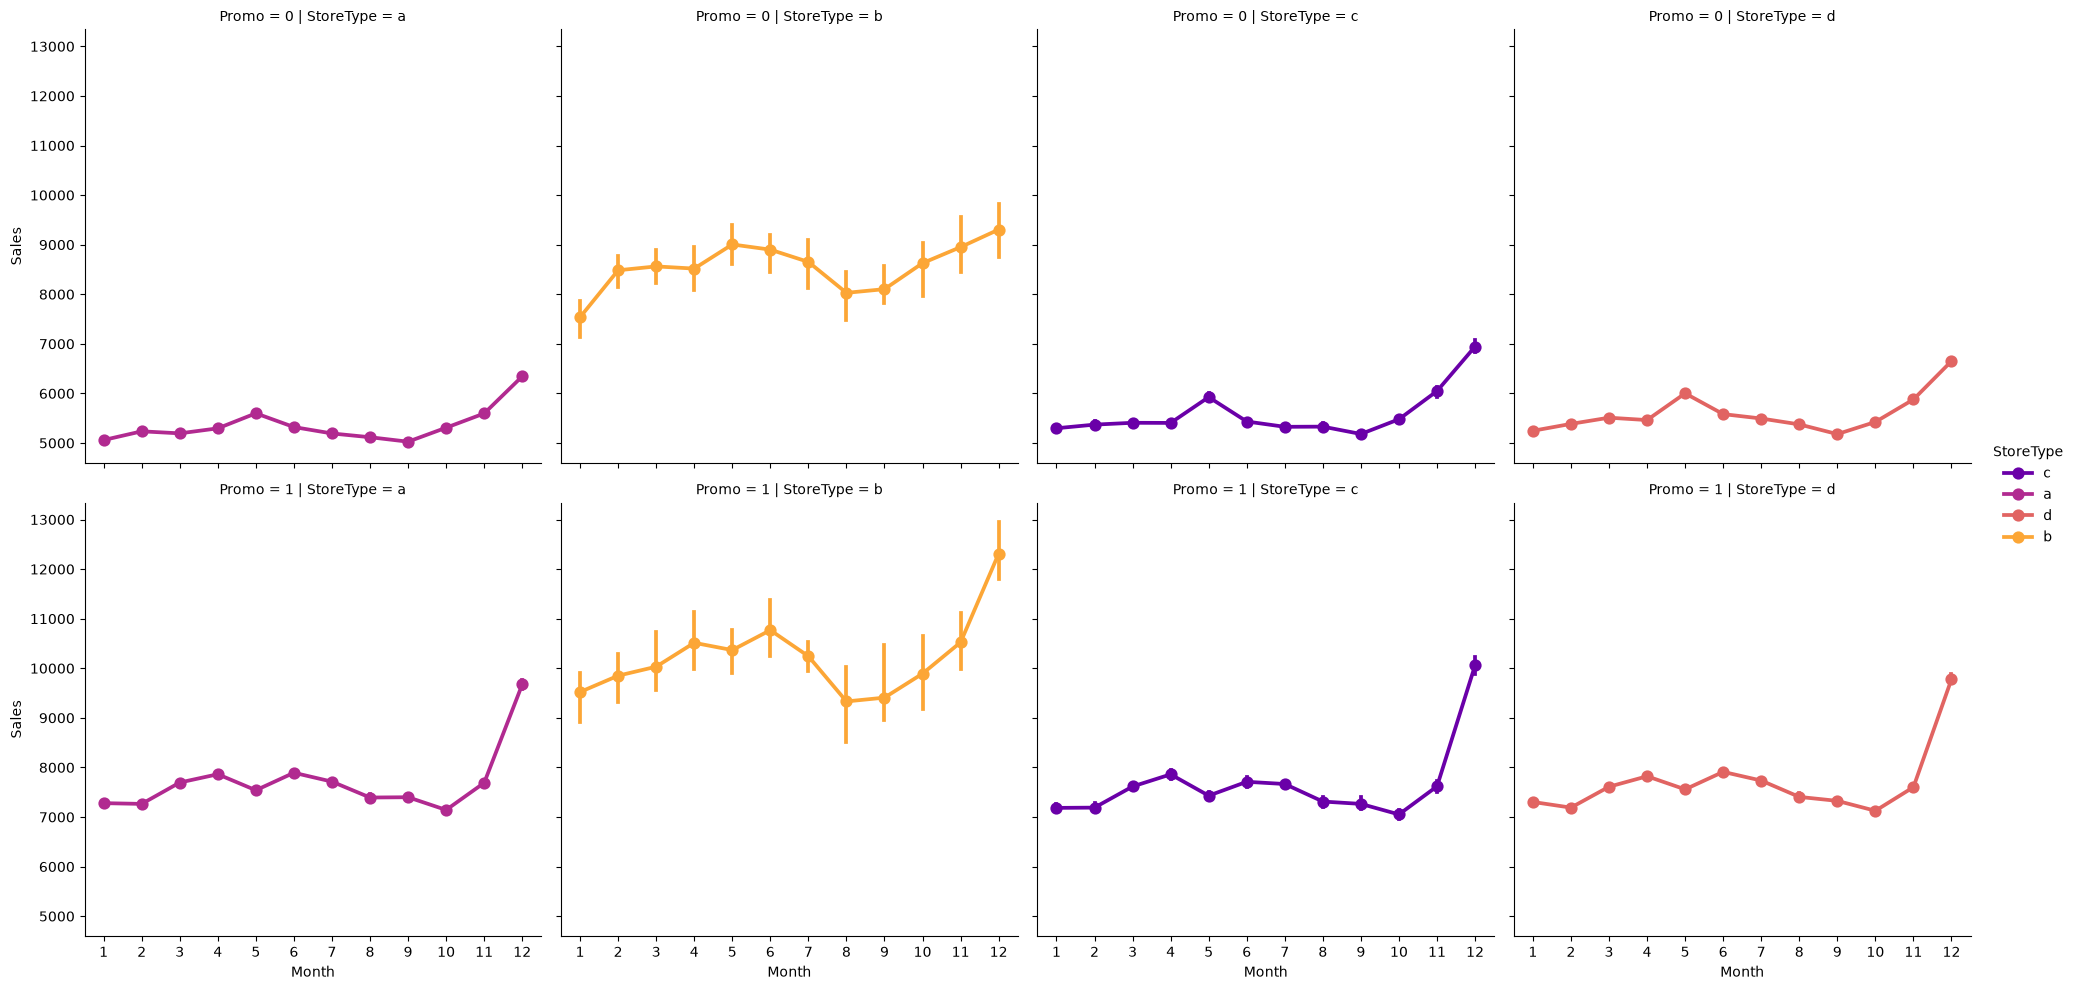

In [116]:
sns.catplot(data=merged_df,
            x='Month', 
            y='Sales',       # sales per day
            col='StoreType', # per store type in cols
            row='Promo',     # per promo in the store in rows
            hue='StoreType',
            palette='plasma',
            col_order=['a', 'b', 'c', 'd'],
            estimator='median',
            kind='point',
            )

Store type **`b`** has the highest median per day sales every Month, with or without promotion (Promo).

**Next:** Let's visualize which `StoreType` has the most median monthly `Customers` for each `StoreType` (a, b, c, d), with and without a promotion:

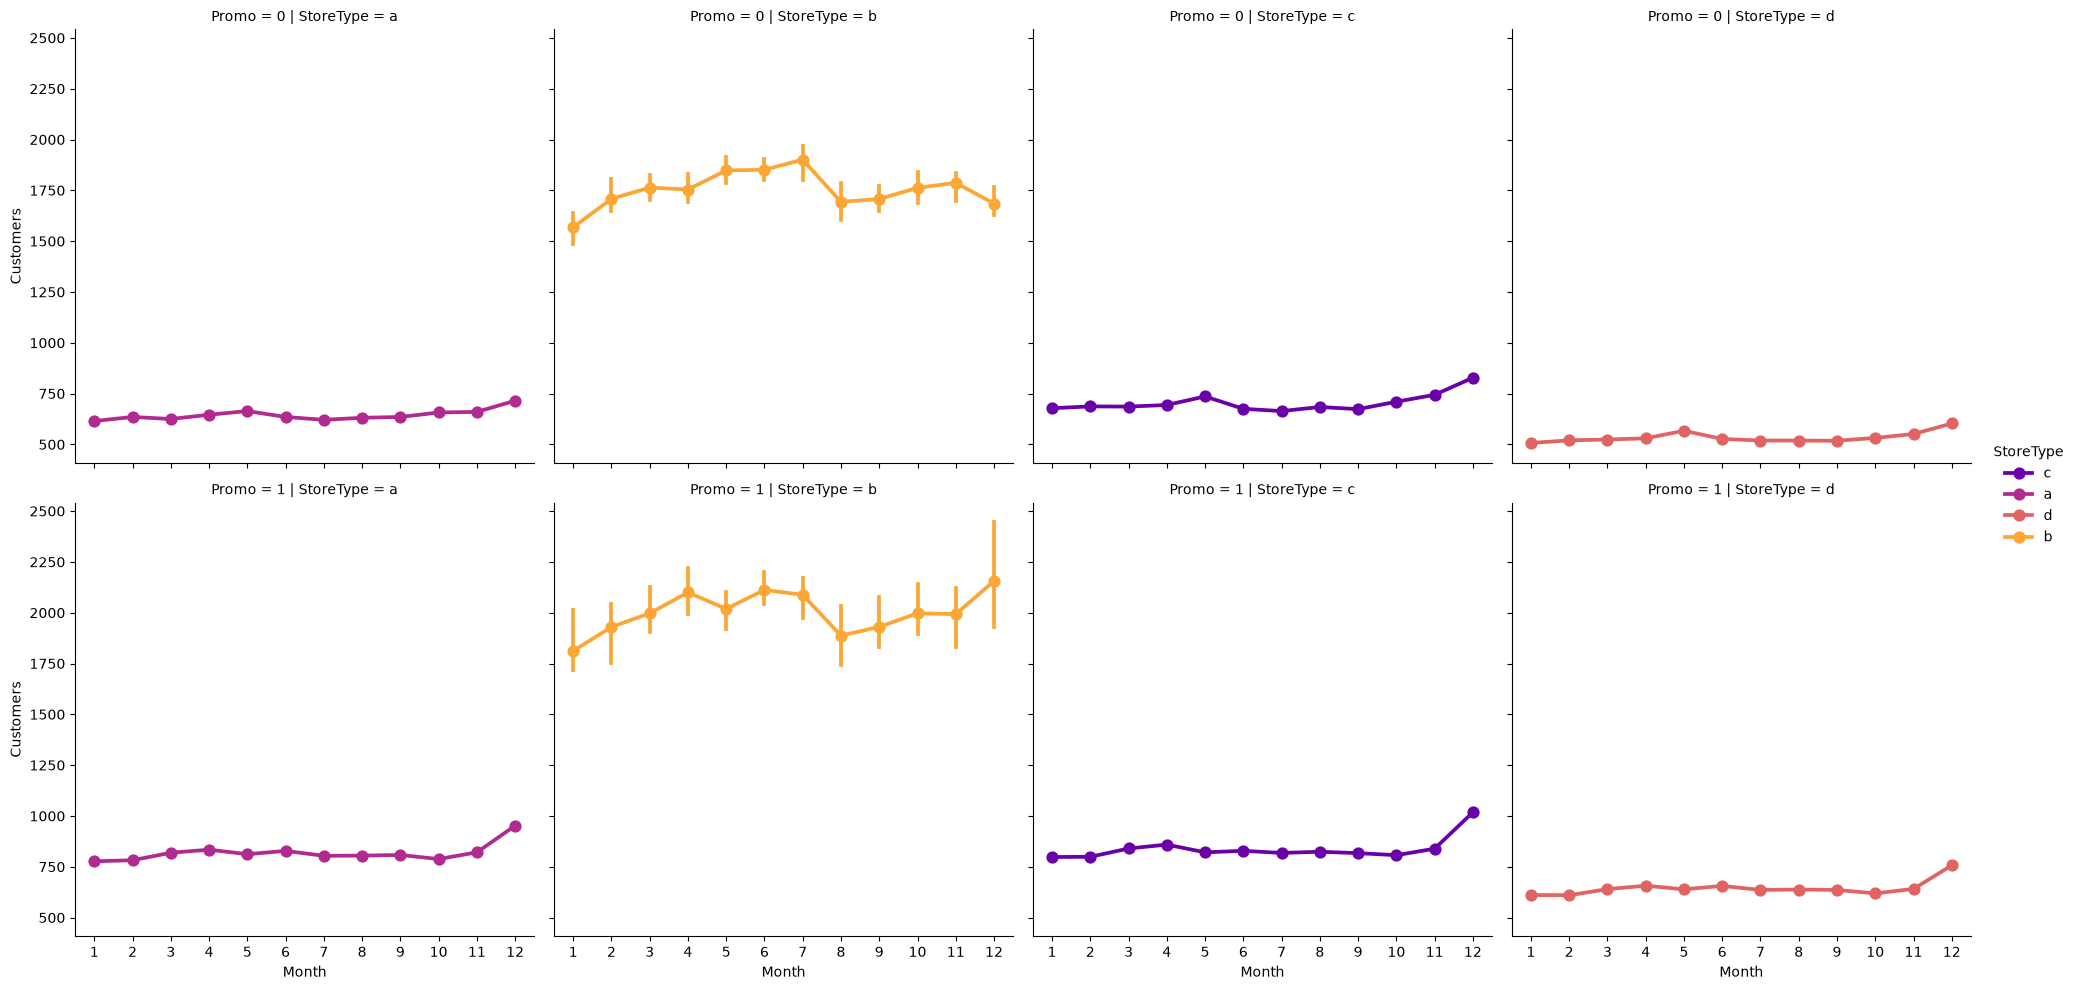

In [117]:
sns.catplot(data=merged_df,
            x='Month', 
            y='Customers',   # Customers per day
            col='StoreType', # per store type in cols
            row='Promo',     # per promo in the store in rows
            hue='StoreType',
            palette='plasma',
            col_order=['a', 'b', 'c', 'd'],
            estimator='median',
            kind='point',
            )

`StoreType b` wins again, it has the most crowd on daily basis in every month. But by looking at the spread,\
it seems that it has less stores compare to others, Let's confirm:

In [118]:
merged_df['StoreType'].value_counts()

StoreType
a    457042
d    258768
c    112968
b     15560
Name: count, dtype: int64

There are least `StoreType b` stores and yet it is the most crowded one with the most sales on daily basis. Lets's investigate why:

In [119]:
merged_df[merged_df['StoreType'] == 'b'].value_counts('Assortment') 

Assortment
b    8209
a    6409
c     942
Name: count, dtype: int64

**`StoreType b`** has the most stores with **Extra / Standard Assortment** (b = 8209), which are generally available in mid-sized locations and they generally have the core essentials plus a few extra top-performing or localized items.

Second most, it has smaller or lower-volume stores with **Basic Assortment** (a = 6409). These stores stock only the essential, top-selling core products that every customer expects.

Lastly, it also has flagship or high-volume stores with **Extended / Advanced Assortment** (c = 942), these stores carry the full range of product categories, specialized items, niche brands, and multiple size variations.


**Next:** Let's save this `merged_df` in a `.csv` file to work with it in another notebook:

In [120]:
merged_df.to_csv(r'./data/merged.csv', index=False)